In [11]:
from ultralytics import YOLO
import os
import cv2
from matplotlib import pyplot as plt

import pydicom
import numpy as np
from PIL import Image

In [90]:
image_name = "d7c148eb16f56462447f7f9c78ce390d"
test_images_dir_path = "assets/test_image"
test_images_path = os.path.join(test_images_dir_path, image_name + '.png')

# image_name = "0a0b773c653cea6653a1e02faf1566a5"

# image_name = "0b029c678b0391bea96cfcc7116b83a1"

# test_images_dir_path = "assets/test_image"
# test_images_path = os.path.join(test_images_dir_path, image_name + '.dicom')

model_path = "model/UltimateXray_yolov8x.pt"

In [91]:
model = YOLO(model_path)

In [92]:
def convert_dicom_to_png_and_resize(dicom_path, png_path):
    dicom = pydicom.dcmread(dicom_path)
    image = dicom.pixel_array
    scaled_image = ((image - np.min(image)) / (np.max(image) - np.min(image)) * 255).astype(np.uint8)
    equalized_image = cv2.equalizeHist(scaled_image)
    resized_image = Image.fromarray(equalized_image).resize((640, 640))
    resized_image.save(png_path)

In [95]:
temp_path = f"assets/test_image/preprocess_{image_name}.png"

if test_images_path.endswith("png"):
    image = cv2.imread(test_images_path, cv2.IMREAD_GRAYSCALE)
    equalized_image = cv2.equalizeHist(image)
    img_resized = cv2.resize(equalized_image, (640, 640))

    cv2.imwrite(temp_path, img_resized)
else:
    convert_dicom_to_png_and_resize(test_images_path, temp_path)

In [96]:
results = model.predict(source=temp_path, conf=0.05)
result = results[0]
result_image = result.plot(show=False)
result_image_rgb = cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB)


image 1/1 c:\Users\TUF_12500H\Desktop\Ultimate-X-ray-AI\assets\test_image\preprocess_d7c148eb16f56462447f7f9c78ce390d.png: 640x640 1 Aortic enlargement, 2 Cardiomegalys, 2 Consolidations, 3 Lung Opacitys, 1 Nodule/Mass, 925.3ms
Speed: 2.5ms preprocess, 925.3ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)


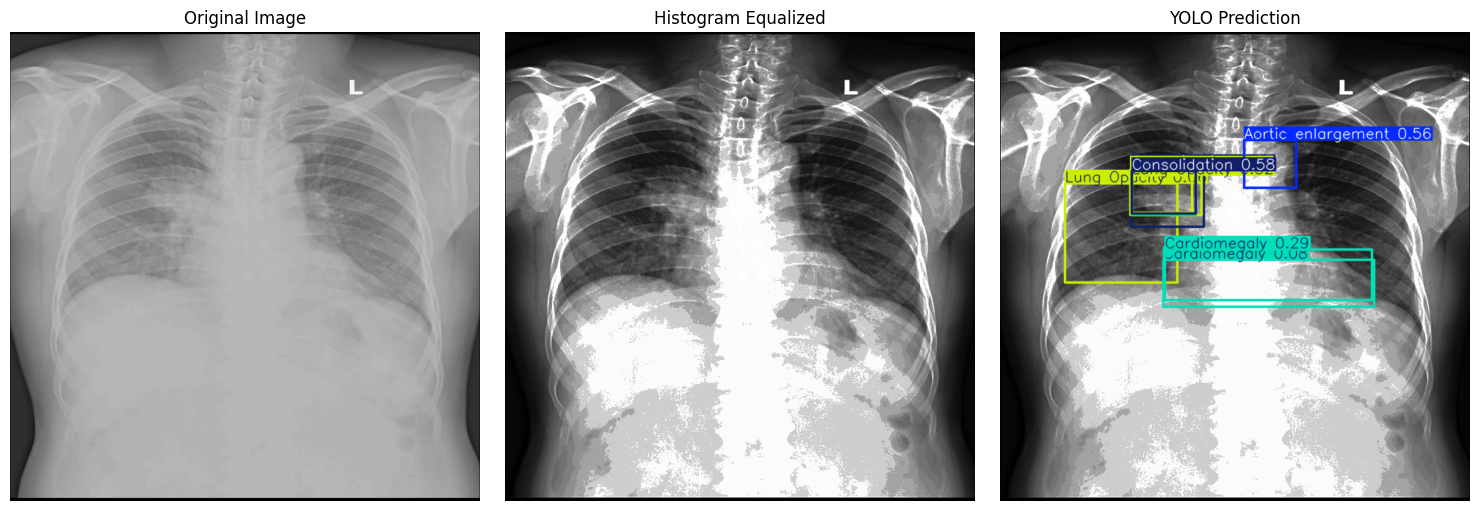

In [99]:
if test_images_path.endswith("dicom"):
    dicom = pydicom.dcmread(test_images_path)
    pixel_array = dicom.pixel_array
    image = Image.fromarray(pixel_array)

    equalized_image = cv2.imread(temp_path, cv2.IMREAD_GRAYSCALE)

# Plot the original, equalized, and result images
plt.figure(figsize=(15, 5))

# Original Image
plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title(f"Original Image")
plt.axis("off")

# Equalized Image
plt.subplot(1, 3, 2)
plt.imshow(equalized_image, cmap='gray')
plt.title("Histogram Equalized")
plt.axis("off")

# YOLO Result
plt.subplot(1, 3, 3)
plt.imshow(result_image_rgb)
plt.title("YOLO Prediction")
plt.axis("off")

plt.tight_layout()
plt.show()